# Human Resource Analytics: Predicting Employee Performance 

## Overview 

The project aspires to empower HR professionals and organizational leaders with actionable intelligence, enabling them to make informed decisions related to talent acquisition, performance management, and employee development. Through the lens of data analytics, we seek to uncover patterns, trends, and correlations that might otherwise remain elusive, ultimately paving the way for more strategic and effective workforce management.

## Objective
Identify High-Performing Employee Profile. Utilize Logistic Regression to Predict if Employee Satisfy Key Performance Indicators (KPIs) Critera.

## Part One: Understanding the Background and Data

**About Dataset**

*Context*
The dataset contains two files. Train and Test.

*Content*
The dataset contains 54808 rows and 14 columns.

*Acknowledgements*
The dataset is taken from Analytical Vidya Practice Hackathon.

**About this file**

employee_id : Unique ID for employee

department : Department of employee

region : Region of employment (unordered)

education : Education Level

gender : Gender of Employee

recruitment_channel : Channel of recruitment for employee

no_of_trainings : no of other trainings completed in previous year on soft skills, technical skills etc.

age : Age of Employee

previous_year_rating : Employee Rating for the previous year

length_of_service : Length of service in years

KPIs_met >80% : if Percent of KPIs(Key performance Indicators) >80% then 1 else 0

awards_won? : if awards won during previous year then 1 else 0

avg_training_score : Average score in current training evaluations

is_promoted: if employee is promoted then 1 else 0

In [31]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_train = pd.read_csv("/kaggle/input/hr-analytics-analytics-vidya/train.csv")
df_test = pd.read_csv("/kaggle/input/hr-analytics-analytics-vidya/test.csv")
df = pd.concat([df_train, df_test], ignore_index=True)
df = df.dropna()

**Information about the data and table example**

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48660 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           48660 non-null  int64  
 1   department            48660 non-null  object 
 2   region                48660 non-null  object 
 3   education             48660 non-null  object 
 4   gender                48660 non-null  object 
 5   recruitment_channel   48660 non-null  object 
 6   no_of_trainings       48660 non-null  int64  
 7   age                   48660 non-null  int64  
 8   previous_year_rating  48660 non-null  float64
 9   length_of_service     48660 non-null  int64  
 10  KPIs_met >80%         48660 non-null  int64  
 11  awards_won?           48660 non-null  int64  
 12  avg_training_score    48660 non-null  int64  
 13  is_promoted           48660 non-null  float64
dtypes: float64(2), int64(7), object(5)
memory usage: 5.6+ MB


In [33]:
df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0.0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0.0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0.0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0.0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0.0


## Part Two: Exploratory Data Analysis

**Descriptive Statistics**

In [34]:
df[["no_of_trainings", "age", "previous_year_rating", "length_of_service", "avg_training_score"]].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
no_of_trainings,48660.0,1.251993,0.604994,1.0,1.0,1.0,1.0,10.0
age,48660.0,35.589437,7.534571,20.0,30.0,34.0,39.0,60.0
previous_year_rating,48660.0,3.337526,1.257922,1.0,3.0,3.0,4.0,5.0
length_of_service,48660.0,6.311570,4.204760,1.0,3.0,5.0,8.0,37.0
avg_training_score,48660.0,63.603309,13.273502,39.0,51.0,60.0,76.0,99.0


**Frequency Analysis**

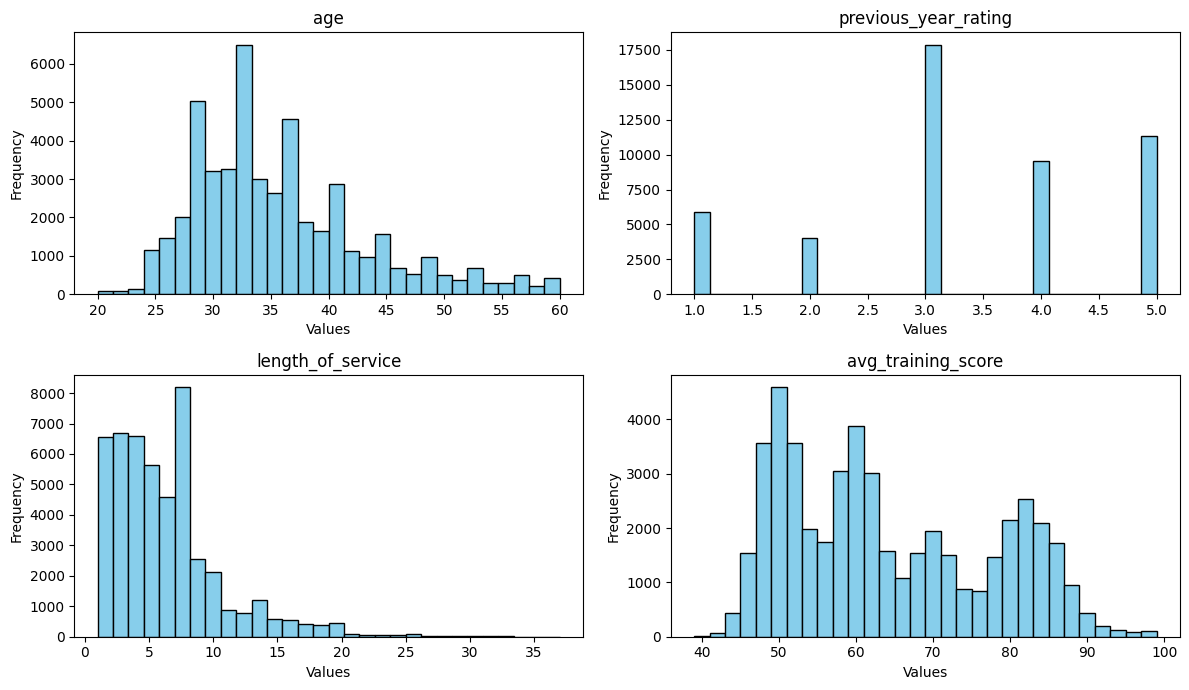

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Subset the DataFrame with the selected columns
subset_df = df[["age", "previous_year_rating", "length_of_service", "avg_training_score"]]

# Create a grid of histograms
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 7))

# Flatten the axes for easy iteration
axes = axes.flatten()

# Loop through selected columns and plot histograms
for i, column in enumerate(subset_df.columns):
    axes[i].hist(subset_df[column], bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(column)
    axes[i].set_xlabel('Values')
    axes[i].set_ylabel('Frequency')

# Adjust layout to prevent overlap
plt.tight_layout()

# Display the plot
plt.show()

## Part Three: Identifying High-Performing Employee Profile
Utilizing people analytics to identify patterns and factors contributing to the success of high-performing profiles within the organisation.

**Exploring the relationship among relevant variables (features) in respect of the groups that satisfy KPI criteria.**

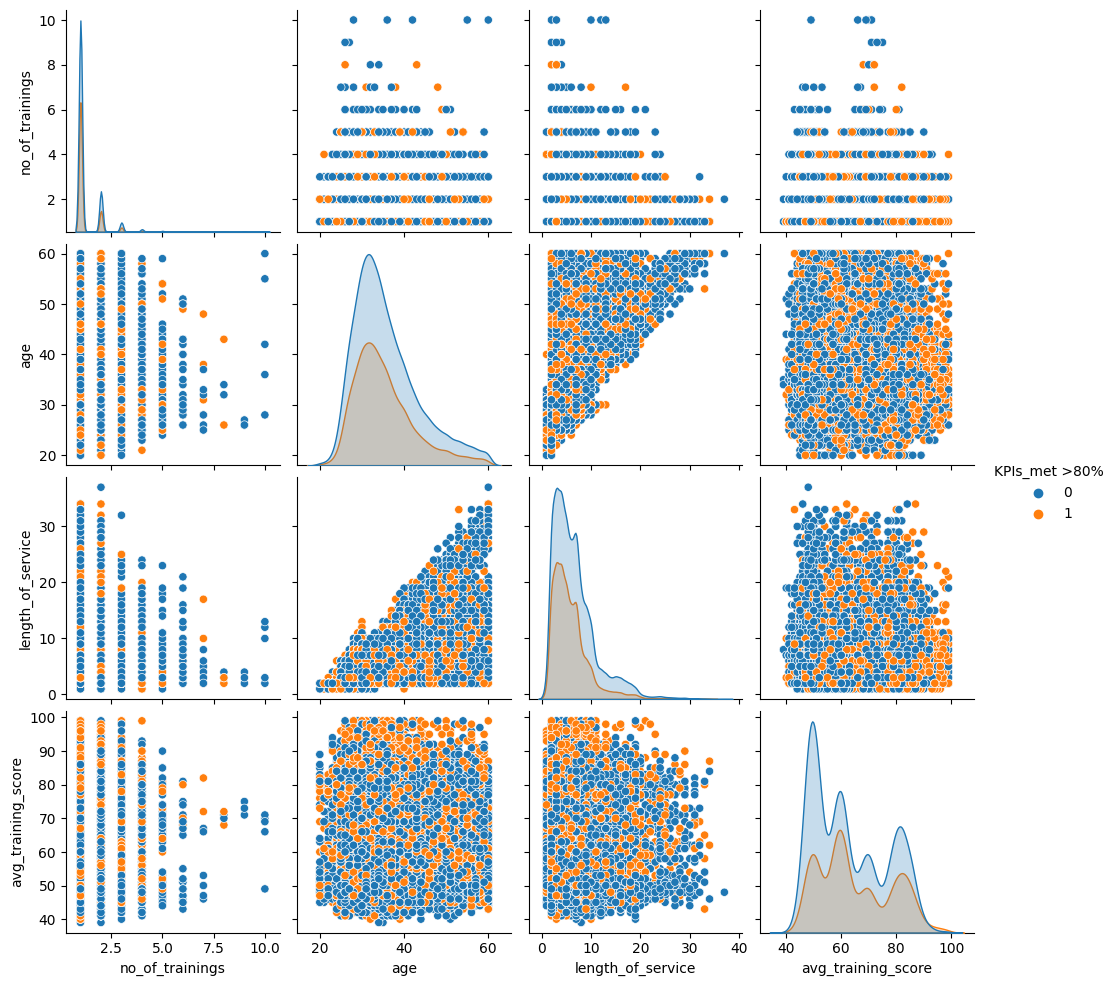

In [36]:
sns.pairplot(data=df[["no_of_trainings", "age", "length_of_service", "avg_training_score", "KPIs_met >80%"]], hue="KPIs_met >80%")

<Axes: >

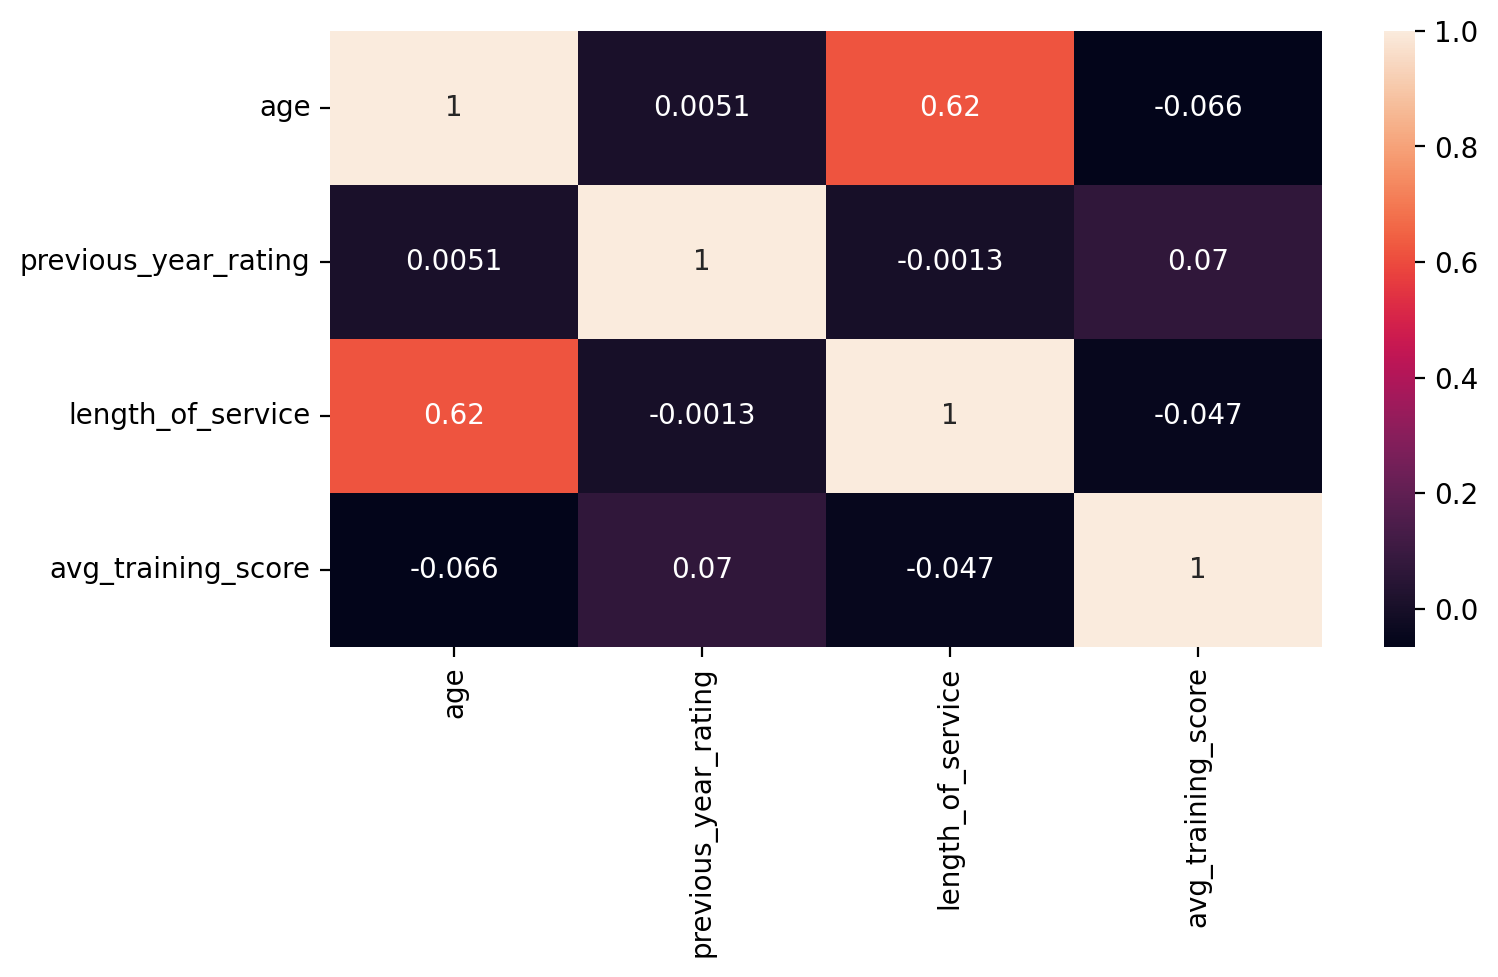

In [37]:
# CODE HERE
plt.figure(figsize=(8,4), dpi=200)
sns.heatmap(subset_df.corr(), annot=True) 

In [38]:
X = df[["age", "previous_year_rating", "length_of_service", "avg_training_score", "no_of_trainings"]]
y = df[["KPIs_met >80%"]]

In [39]:
from sklearn.model_selection import train_test_split, GridSearchCV
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

In [40]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_X_train = scaler.fit_transform(X_train)
scaled_X_test = scaler.transform(X_test)

In [41]:
from sklearn.linear_model import LogisticRegression
log_model = LogisticRegression()
log_model.fit(scaled_X_train,y_train.values.ravel())
coef = log_model.coef_

**Logistic Regression Model**

Coefficients for each feature in the model

In [42]:
#CODE HERE
coefdf = pd.DataFrame(coef)
coefdf.columns = X.columns
# coefdfsort = coefdf.sort_values(by=coefdf.columns, axis=1)
coefdf
# Select the row you want to use for sorting (e.g., row 0)
sorting_row = coefdf.loc[0]
# Sort the columns based on the values in the selected row
sorted_df = coefdf[sorting_row.sort_values().index]
sorted_df.index = ["correlation coefficients"]
sorted_df

,length_of_service,no_of_trainings,age,avg_training_score,previous_year_rating
correlation coefficients,-0.267713,-0.080616,0.071724,0.131911,0.847768


<Axes: >

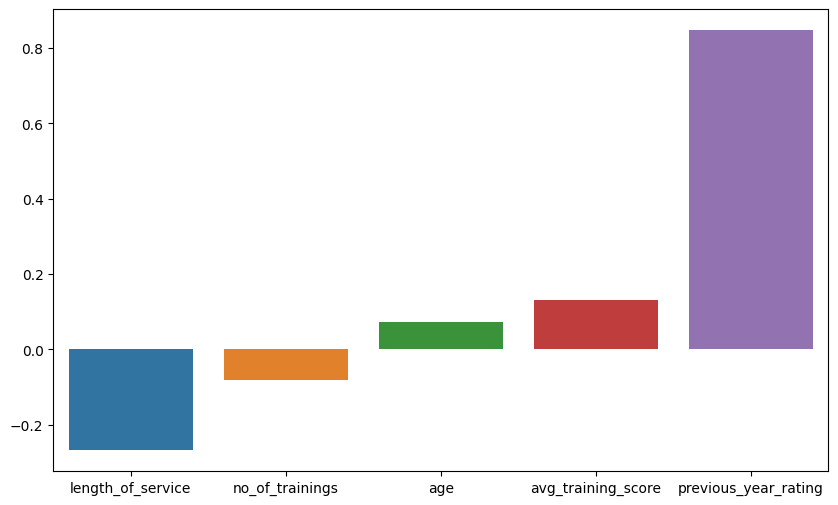

In [43]:
plt.figure(figsize=(10,6))
sns.barplot(data=sorted_df)

The coefficients suggest that the previous year's rating has the highest impact on the probability of classifying an employee into a group that satisfies KPI criteria. A positive coefficient for the previous year's rating indicates an increase in the log-odds of belonging to the KPI group. In contrast, other features have coefficients with smaller magnitudes, suggesting lower influence on the likelihood of classifying an employee into (or out of) the group that satisfies KPI criteria. These findings imply that, among the considered features, the previous year's rating has the strongest association with meeting KPI criteria.

In [44]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,ConfusionMatrixDisplay

y_pred = log_model.predict(scaled_X_test)
accuracy = accuracy_score(y_test,y_pred)

In [45]:
conMatrix = confusion_matrix(y_test,y_pred)

*Confusion Matrix*

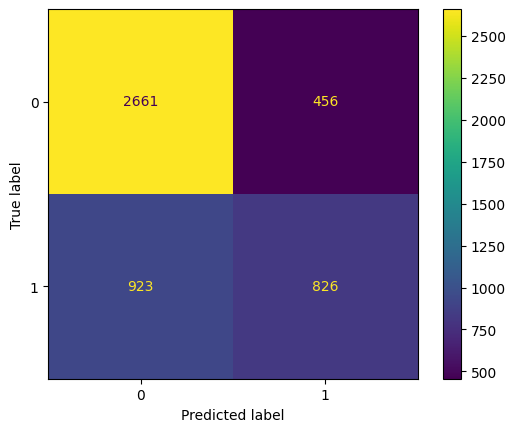

In [46]:
disp = ConfusionMatrixDisplay(confusion_matrix=conMatrix)
disp.plot()

The model correctly classified 2661 employees as not belonging to the KPI group, and incorrectly classified 456 employees as belonging to the KPI group when they do not. Additionally, the model incorrectly classified 923 employees as not belonging to the KPI group when they actually do, and correctly classified 826 employees as belonging to the KPI group.

**Model Performance**

In [47]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.74      0.85      0.79      3117
           1       0.64      0.47      0.55      1749

    accuracy                           0.72      4866
   macro avg       0.69      0.66      0.67      4866
weighted avg       0.71      0.72      0.70      4866



**Precision**:

For class 0 (employees not belonging to the KPI group), the precision is 0.74. This means that out of all instances predicted as not belonging to the KPI group, 74% were correct.
For class 1 (employees belonging to the KPI group), the precision is 0.64. This means that out of all instances predicted as belonging to the KPI group, 64% were correct.

**Recall**:

For class 0, the recall is 0.85. This indicates that the model correctly identified 85% of all instances where employees did not belong to the KPI group.
For class 1, the recall is 0.47. This indicates that the model correctly identified 47% of all instances where employees did belong to the KPI group.

**F1-score**:

For class 0, the F1-score is 0.79. The F1-score is the harmonic mean of precision and recall, providing a balanced measure.
For class 1, the F1-score is 0.55. Similar to class 0, it balances precision and recall.

**Support**:

The support represents the number of actual occurrences of each class in the specified dataset. In this case, there are 3117 instances of class 0 and 1749 instances of class 1.

**Accuracy**:

The overall accuracy of the model is 0.72, meaning that the model correctly predicted the class for 72% of the instances.

**Macro Avg**:

The macro average of precision, recall, and F1-score is computed by averaging the metrics for each class. In this case, it's showing an average precision of 0.69, average recall of 0.66, and average F1-score of 0.67.

**Weighted Avg**:

The weighted average takes into account the number of instances for each class. It is weighted by the number of samples in each class. In this case, it's showing a weighted average precision of 0.71, weighted average recall of 0.72, and weighted average F1-score of 0.70.

Overall, this model has decent precision and recall for class 0 but lower precision and recall for class 1. The F1-score provides a balanced measure, and the weighted average considers the class imbalance in dataset. Depending on the specific goals and constraints of organisation problem, future analysis can be focused on improving the model's performance on class 1 if it is more critical to your application.

*Precision_Recall curve*

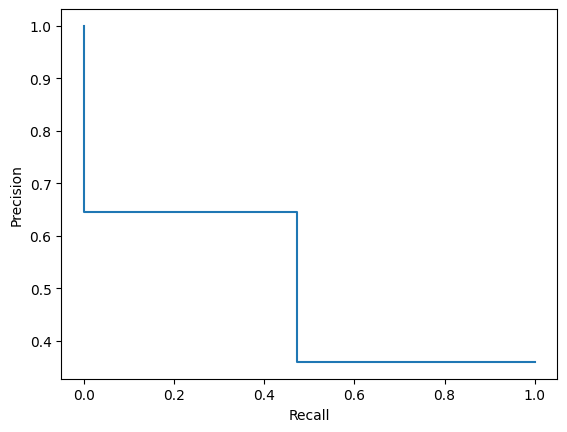

In [48]:
from sklearn.metrics import PrecisionRecallDisplay, RocCurveDisplay,precision_recall_curve
precision, recall, _ = precision_recall_curve(y_test, y_pred)
disp = PrecisionRecallDisplay(precision=precision, recall=recall)
disp.plot()

Precision is the number of true positives divided by the sum of true positives and false positives. It represents the accuracy of positive predictions.
Recall (or sensitivity) is the number of true positives divided by the sum of true positives and false negatives. It represents the ability of the model to capture all positive instances. Consider the trade-off between precision and recall at different decision thresholds.

*ROC curve*

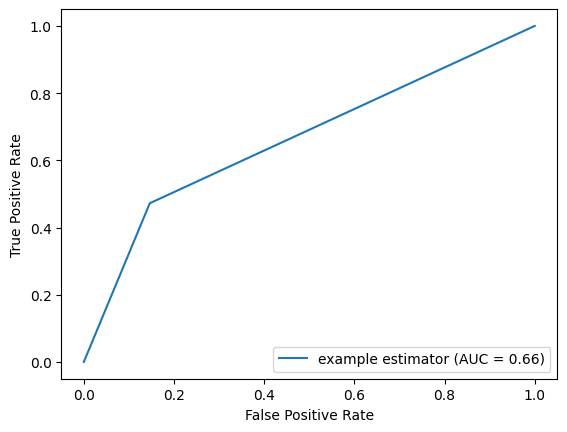

In [49]:
from sklearn import metrics
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc, estimator_name='example estimator')
display.plot()

The ROC (Receiver Operating Characteristic) curve follows model metrics, especially confusion matrix and shows that the model missclasify (False Positive Rate) quite moderate proportion of the cases. The AUC (Area Under the Curve) of the ROC curve is a measure of the model's ability to discriminate between the positive and negative classes. An AUC of 0.66 suggests that the model has a moderate ability to distinguish between the positive and negative classes. In more practical terms: If you randomly select a positive instance and a negative instance, the model will correctly rank them with the positive instance having a higher predicted probability about 66% of the time.

**Predicting if employee X will satisfy KPI criteria**

Employee X features:

In [50]:
employeeS = X_test.iloc[0]
employee = [employeeS.values.tolist()]
employeeS

age                     45.0
previous_year_rating     3.0
length_of_service        7.0
avg_training_score      89.0
no_of_trainings          1.0
Name: 26182, dtype: float64

*Model Prediction* for the employee X (1-satisfy KPI criteria)

In [51]:
prediction = log_model.predict(employee)
print(f"Model predict that employee X belongs to group {prediction[0]}")

Model predict that employee X belongs to group 1


In [52]:
pred_coef = log_model.predict_proba(employee)
print(f"Model Prediction Coefficient for Classfying Employee: {pred_coef[0]}")

Model Prediction Coefficient for Classfying Employee: [3.56889705e-07 9.99999643e-01]


Employee X have a high chance to belong to the group that have KPI over 80%, and based on our model metrics, there is 64% that we are correct in our prediction.

# Conclusion

It depends on the nature of the proposed question we are trying to answer. That is, if the question requires high precision, for example, predicting if a person has a health issue, we should apply only the models that present a high degree of precise discrimination. But, if we have a limited, hardly accessible dataset, our model (with lower performance) can be useful. It can give us valuable information about the features that come up as relevant and acknowledge the results for further decision models (i.e. what factors to take into account if we want to predict which employee will meet our KPI criteria).